In [1]:
from IPython.display import display
import pandas as pd
def describe_dataset(df: pd.DataFrame):
    display(df.describe())
    display(df['target'].value_counts())


In [2]:
# Standardize Dataset
import pandas as pd
import numpy as np
from config import RANDOM_STATE_SEED
from preprocessing import standardize

def standardize_and_plot_pca(df: pd.DataFrame) -> pd.DataFrame:

    df = standardize(df)
    # Set our RNG seed for reproducibility.
    np.random.seed(RANDOM_STATE_SEED)
    X_raw: pd.DataFrame = df.loc[:, df.columns != 'target']#.to_numpy()
    y_raw: pd.DataFrame = df['target']#.to_numpy()
    # PCA decomposition
    from sklearn.decomposition import PCA

    # Define our PCA transformer and fit it onto our raw dataset.
    pca = PCA(n_components=2, random_state=RANDOM_STATE_SEED)
    transformed_df = pca.fit_transform(X=X_raw)
    %matplotlib inline
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    # Isolate the data we'll need for plotting.
    x_component, y_component = transformed_df[:, 0], transformed_df[:, 1]

    # Plot our dimensionality-reduced (via PCA) dataset.
    plt.figure(figsize=(8.5, 6), dpi=130)
    plt.scatter(x=x_component, y=y_component, c=y_raw, cmap='viridis', s=50, alpha=8/10)
    plt.title('Df classes after PCA transformation')
    plt.show()

    return df

In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from models import SGDLogClassifier, SGDModifiedHuberClassifier
from sklearn.model_selection import train_test_split
from metrics import method_eval

def partial_test_dataset(df: pd.DataFrame):
    dataset_percentages = [10, 30, 50, 70, 90]
    models = [GaussianNB(), KNeighborsClassifier(), SGDLogClassifier(random_state=RANDOM_STATE_SEED), SGDModifiedHuberClassifier(random_state=RANDOM_STATE_SEED)]

    X = df.loc[:, df.columns != 'target']
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

    for model in models:
        print(f"{model.__class__.__name__}\n")
        for p in dataset_percentages:
            size = len(X_train)
            part_of_dataset = int(p/100*size)
            # Randomly sample percentage of dataset
            X = X_train.sample(n=part_of_dataset, random_state=RANDOM_STATE_SEED)
            y = y_train.loc[X.index]
            # Train model on this part
            model.fit(X, y)
            # Evaluate the model
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)
            # Compare model's results
            print(f"Results for {p}%: \n")
            method_eval(y_test, y_pred, y_proba, verbose=1, curves=False)
            print("\n")

,ip_mean,ip_std,ip_excess_curtosis,ip_skewness,dmsnr_mean,dmsnr_std,dmsnr_excess_curtosis,dmsnr_skewness,target
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


0    16259
1     1639
Name: target, dtype: int64

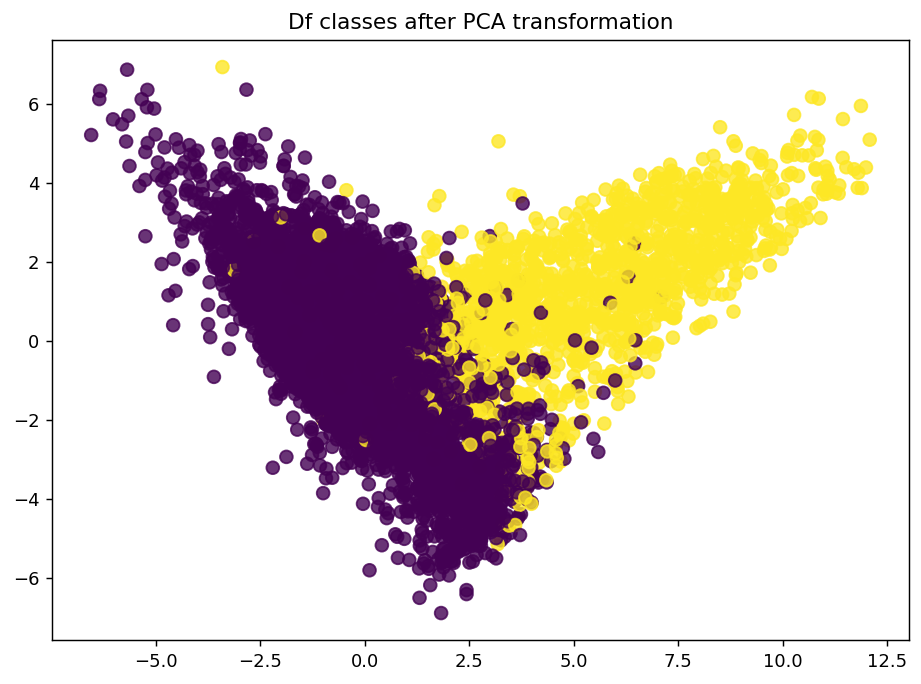

GaussianNB

Results for 10%: 

accuracy: 0.9452513966480447,
precision: 0.6534883720930232,
recall: 0.8567073170731707,
f2_score: 0.80654420206659,
auc_pr_curve: 0.882907661670031,
auc_roc_curve: 0.9639780772807729


Results for 30%: 

accuracy: 0.9449720670391062,
precision: 0.6519721577726219,
recall: 0.8567073170731707,
f2_score: 0.8060814687320712,
auc_pr_curve: 0.8821844561769376,
auc_roc_curve: 0.9641510477604777


Results for 50%: 

accuracy: 0.9460893854748603,
precision: 0.6595744680851063,
recall: 0.850609756097561,
f2_score: 0.8040345821325648,
auc_pr_curve: 0.8834376658178749,
auc_roc_curve: 0.9643118306183062


Results for 70%: 

accuracy: 0.9449720670391062,
precision: 0.6526806526806527,
recall: 0.8536585365853658,
f2_score: 0.80413555427915,
auc_pr_curve: 0.8821367341823988,
auc_roc_curve: 0.9640990159901599


Results for 90%: 

accuracy: 0.9441340782122905,
precision: 0.6467889908256881,
recall: 0.8597560975609756,
f2_score: 0.8066361556064073,
auc_pr_curve: 0.88162326

In [4]:
import pandas as pd

column_names = ["ip_mean", "ip_std", "ip_excess_curtosis", "ip_skewness", "dmsnr_mean", "dmsnr_std", "dmsnr_excess_curtosis", "dmsnr_skewness", "target"]
df = pd.read_csv("../data/HTRU2/HTRU_2.csv", header=None, names=column_names)

describe_dataset(df)
df = standardize_and_plot_pca(df)
partial_test_dataset(df)
